In [1]:
import geopandas as gpd
import osmnx as ox 
from pathlib import Path

In [33]:
from shapely.geometry import Point
from shapely.geometry import LineString

In [14]:
import matplotlib.pyplot as plt

In [2]:
print(Path.cwd())

d:\Wu\2026\Project Portfolio\002 Project\grocery_stores_access\notebooks


In [9]:
G = ox.load_graphml("../data/processed/kootenai_drive.graphml")

In [ ]:
stores = gpd.read_file("data/processed/stores_points_with_cities.gpkg")

In [ ]:
stores.columns

In [ ]:
len(stores)

In [ ]:
stores[["name", "addr:city", "city", "addr:street", "geometry_type", "geometry"]].sort_values(["name"])

In [ ]:
stores.crs

In [ ]:
# OpenStreeMap uses WGS84 (4326)
stores = stores.to_crs(4326)

In [ ]:
stores['x'] = stores.geometry.x
stores['y'] = stores.geometry.y

In [ ]:
stores["nearest_node"] = ox.distance.nearest_nodes(
    G,
    stores['x'],
    stores['y']
)

In [ ]:
stores[["name", "addr:city", "nearest_node"]]

In [ ]:
stores.to_file("data/processed/stores_nearest_nodes.gpkg", driver="GPKG")

### Verify node assignment

In [4]:
stores = gpd.read_file("../data/processed/stores_nearest_nodes.gpkg")

In [5]:
store = stores.iloc[0]

print(store["name"])
print(store["nearest_node"])

Grocery Outlet
8556346272


In [ ]:
# Both store and G are in EPSG 4326
node_id = store["nearest_node"]
node = G.nodes[node_id]
print(node["x"], node["y"])

-116.7944285 47.70499


In [13]:
node_gdf = gpd.GeoDataFrame(
    {"node_id": [node_id]},
    geometry=[Point(node["x"], node["y"])],
    crs="EPSG:4326"
)

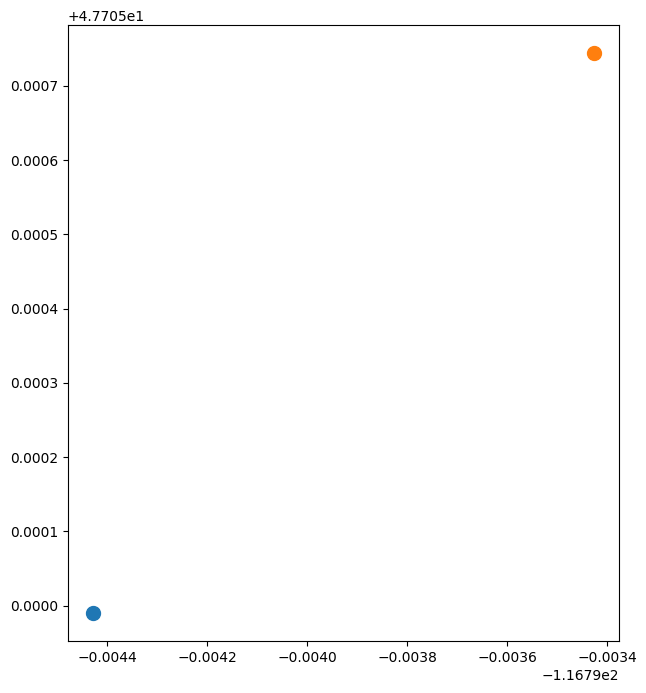

In [16]:
# Plot store and node together
fig, ax = plt.subplots(figsize=(8,8))
node_gdf.plot(
    ax=ax,
    markersize=100
)

stores.iloc[[0]].plot(
    ax=ax,
    markersize=100
)

plt.show()

### Calculate actual distance

In [17]:
# Project both to UTM
store_gdf = stores.iloc[[0]].copy()
store_gdf = store_gdf.to_crs(26911)
node_gdf = node_gdf.to_crs(26911)

In [18]:
# Calculate distance
distance_m = (
    store_gdf.geometry.iloc[0]
    .distance(node_gdf.geometry.iloc[0])
)
print(f"{distance_m: .1f} meters")

 112.6 meters


### Check all stores

In [20]:
stores["node_geometry"] = stores["nearest_node"].apply(
    lambda n: Point(
        G.nodes[n]["x"],
        G.nodes[n]["y"]
    )
)

In [21]:
# Create node GeoDataFrame
nodes_gdf = gpd.GeoDataFrame(
    stores[["name"]],
    geometry=stores["node_geometry"],
    crs="EPSG:4326"
)

In [22]:
# Project
stores26911 = stores.to_crs(26911)
nodes26911 = nodes_gdf.to_crs(26911)


In [23]:
# Distance
stores["node_distance_m"] = (
    stores26911.geometry.distance(
        nodes26911.geometry
    )
)

In [25]:
stores[
    ["name", "addr:city", "node_distance_m"]
].sort_values("node_distance_m", ascending=False)

,name,addr:city,node_distance_m
18,Super One Foods,Athol,276.627431
14,WinCo Foods,Coeur d'Alene,187.926186
8,Walmart Supercenter,Post Falls,180.551057
4,Albertsons,Hayden,177.607651
6,Safeway,Coeur d'Alene,159.900481
7,Walmart Supercenter,Post Falls,155.222457
2,Target,Coeur d'Alene,142.750995
17,Walmart Supercenter,Hayden,135.349901
10,Safeway,Coeur d'Alene,126.985138
23,Super One Foods,Coeur d'Alene,119.236200


In [42]:
stores.to_file("../data/processed/grocery_store_nodes.gpkg", driver="GPKG")

### Map for Super One Foods

In [26]:
store = stores[
    (stores["name"] == "Super One Foods")
    & (stores["addr:city"] == "Athol")
].iloc[0]

store

element                                                                     way
id                                                                    886523884
addr:city                                                                 Athol
addr:housenumber                                                            NaN
addr:postcode                                                               NaN
addr:street                                                                 NaN
name                                                            Super One Foods
opening_hours                                                              24/7
shop                                                                supermarket
brand                                                                       NaN
brand:wikidata                                                              NaN
official_name                                                               NaN
addr:state                              

In [27]:
# Get its nearest node
node_id = store["nearest_node"]

node_x = G.nodes[node_id]["x"]
node_y = G.nodes[node_id]["y"]

In [ ]:
# Create a GeoDataFrame 
node_gdf = gpd.GeoDataFrame(
    {"node_id": [node_id]},
    geometry=[Point(node_x, node_y)],
    crs="EPSG:4326"
)

In [29]:
# Create a small bounding box around the store
buffer = 0.005  # about 500m

xmin = store.geometry.x - buffer
xmax = store.geometry.x + buffer

ymin = store.geometry.y - buffer
ymax = store.geometry.y + buffer

In [34]:
line = LineString([
    store.geometry,
    node_gdf.geometry.iloc[0]
])

line_gdf = gpd.GeoDataFrame(
    geometry=[line],
    crs="EPSG:4326"
)

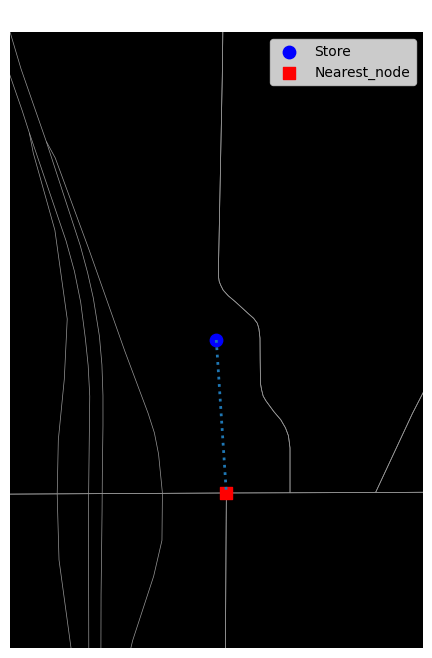

In [41]:
# Plot road network, store, and the nearest node
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_linewidth=0.5,
    show=False,
    close=False
)
ax.set_facecolor("black")

store_gdf = gpd.GeoDataFrame(
    [store],
    geometry="geometry",
    crs=stores.crs
)

store_gdf.plot(
    ax=ax,
    markersize=80,
    marker="o",
    color="blue",
    label="Store"
)

node_gdf.plot(
    ax=ax,
    markersize=80,
    marker="s",
    color="red",
    label="Nearest_node"
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

line_gdf.plot(
    ax=ax,
    linewidth=2,
    linestyle=":"
)

plt.title(
    "Super One Foods (Athol)",
    color="white")
plt.legend()
plt.show()